# Quantum Advantage Feasibility Checklist

**Motivating question:** What should we ask before calling a claimed quantum speedup believable, unclear, or hype-prone?

**Learning goals**
- treat quantum advantage as an end-to-end systems claim rather than a slogan
- evaluate whether a problem's structure actually supports the hope of quantum advantage
- connect problem class, input/output assumptions, and hardware overhead into one judgment framework
- recognize why weak classical baselines can distort performance claims
- practice classifying toy case studies as plausible, unclear, or hype-prone

*This notebook accompanies Lecture 03 on computational complexity. It is designed for live demo and self-study.*


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'utilities' / 'complexity_utils.py').exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown

from utilities.complexity_utils import (
    display_wrapped,
    instructor_prompt,
    markdown_box,
    plot_baseline_comparison,
    plot_case_study_matrix,
    plot_checklist_ladder,
    plot_evaluation_funnel,
    plot_grouped_bars,
    plot_io_constraint_summary,
    plot_problem_class_map,
    plot_stacked_cost_bars,
    setup_lecture_style,
)

setup_lecture_style()
pd.options.display.float_format = lambda value: f'{value:,.3g}'


This notebook follows the shared Lecture 03 visual rhythm: a motivating question, a small model, one dominant visual, a compact comparison, and a short takeaway.

This notebook closes the sequence by turning the earlier ideas into a judgment framework. The goal is not to introduce a new mechanism, but to evaluate quantum speedup claims with the same discipline we used for scaling, representation, and system-level cost.

## 1. What should we ask before believing a speedup claim?

**Concept question:** If someone says “quantum is faster here,” what sequence of checks should we make before accepting the claim?


This notebook is a synthesis and evaluation tool. Its purpose is not to introduce a new algorithmic mechanism. Instead, it collects the ideas from the earlier notebooks into a disciplined checklist for judging whether a speedup claim is plausible, unclear, or hype-prone.

The guiding attitude is sober: a claim becomes stronger only if it survives several independent questions.


In [2]:
checklist_stages = [
    'speedup claim appears',
    'problem structure looks promising',
    'problem class does not already signal obvious difficulty',
    'input / output assumptions are realistic',
    'hardware and mapping overhead are manageable',
    'classical baseline is strong and fair',
    'end-to-end judgment becomes more credible',
]

opening_checklist_df = pd.DataFrame(
    {
        'Question': [
            'Does the claim rely on exploitable structure?',
            'What problem class are we actually talking about?',
            'How expensive is input loading and output extraction?',
            'What hardware overheads are being paid?',
            'Is the classical comparison strong and honest?',
        ],
        'Why it matters': [
            'quantum speedups are rarely structure-free',
            'class language constrains what is plausible',
            'end-to-end cost can erase a core gain',
            'mapping, routing, and shots are real costs',
            'weak baselines can manufacture artificial wins',
        ],
    }
)


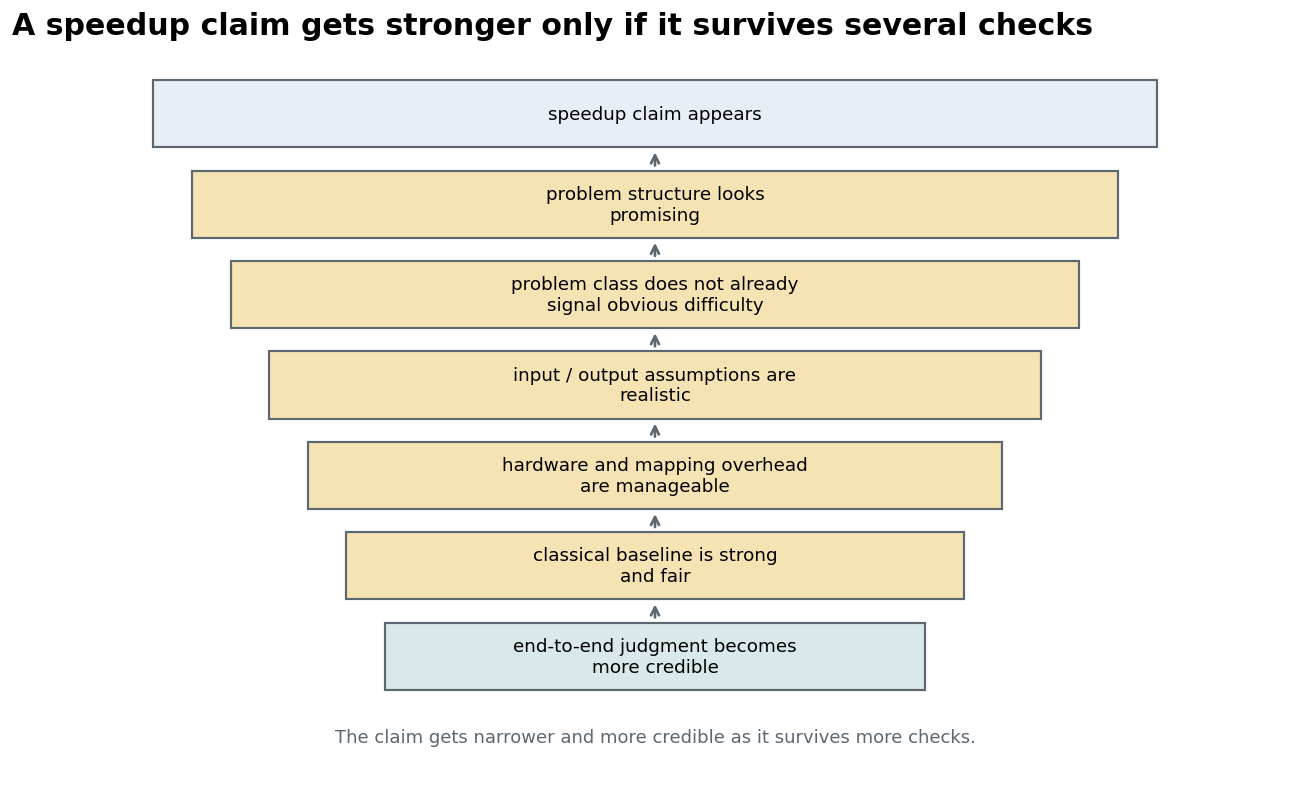

In [3]:
plot_evaluation_funnel(
    checklist_stages,
    title='A speedup claim gets stronger only if it survives several checks',
)
plt.show()


The funnel should be read as a discipline device. Early excitement is easy; strong end-to-end judgment is harder. Each surviving stage removes one common source of overclaiming.


In [4]:
display_wrapped(opening_checklist_df)


,Question,Why it matters
0,Does the claim rely on exploitable structure?,quantum speedups are rarely structure-free
1,What problem class are we actually talking about?,class language constrains what is plausible
2,How expensive is input loading and output extraction?,end-to-end cost can erase a core gain
3,What hardware overheads are being paid?,"mapping, routing, and shots are real costs"
4,Is the classical comparison strong and honest?,weak baselines can manufacture artificial wins


In [5]:
display_wrapped(Markdown(markdown_box(
    'A speedup claim is only a starting point. Credibility comes from surviving a sequence of structure, class, I/O, hardware, and baseline checks.'
)))


> **Takeaway:**
> A speedup claim is only a starting point. Credibility comes from surviving a sequence of structure, class, I/O, hardware, and baseline checks.

In [6]:
display_wrapped(Markdown(instructor_prompt(
    'Which checklist question do you think people skip most often when presenting a quantum advantage claim?'
)))


> **Instructor Prompt:**
> Which checklist question do you think people skip most often when presenting a quantum advantage claim?

## 2. Checklist 1: Does the problem structure support quantum advantage?

**Concept question:** Is there exploitable structure, or does the task look like an arbitrary black box with little to work with?


“Problem structure” means features that an algorithm can exploit: algebraic regularity, locality, symmetries, sparse interactions, or natural dynamics that already resemble the computational model. In contrast, arbitrary generic data with no helpful pattern is usually harder to turn into a convincing advantage claim.


In [7]:
structure_df = pd.DataFrame(
    {
        'Problem family': [
            'generic database lookup',
            'local physical simulation',
            'periodic / algebraic hidden structure',
            'sparse graph walk structure',
            'arbitrary dense table processing',
        ],
        'Structure promise score': [1, 5, 5, 4, 1],
        'Why': [
            'little algorithmic leverage beyond raw access',
            'the problem already has quantum-like locality and interference structure',
            'regularity can support specialized algorithmic tricks',
            'connectivity pattern may create exploitable dynamics',
            'dense arbitrary data often behaves like a loading problem first',
        ],
    }
)


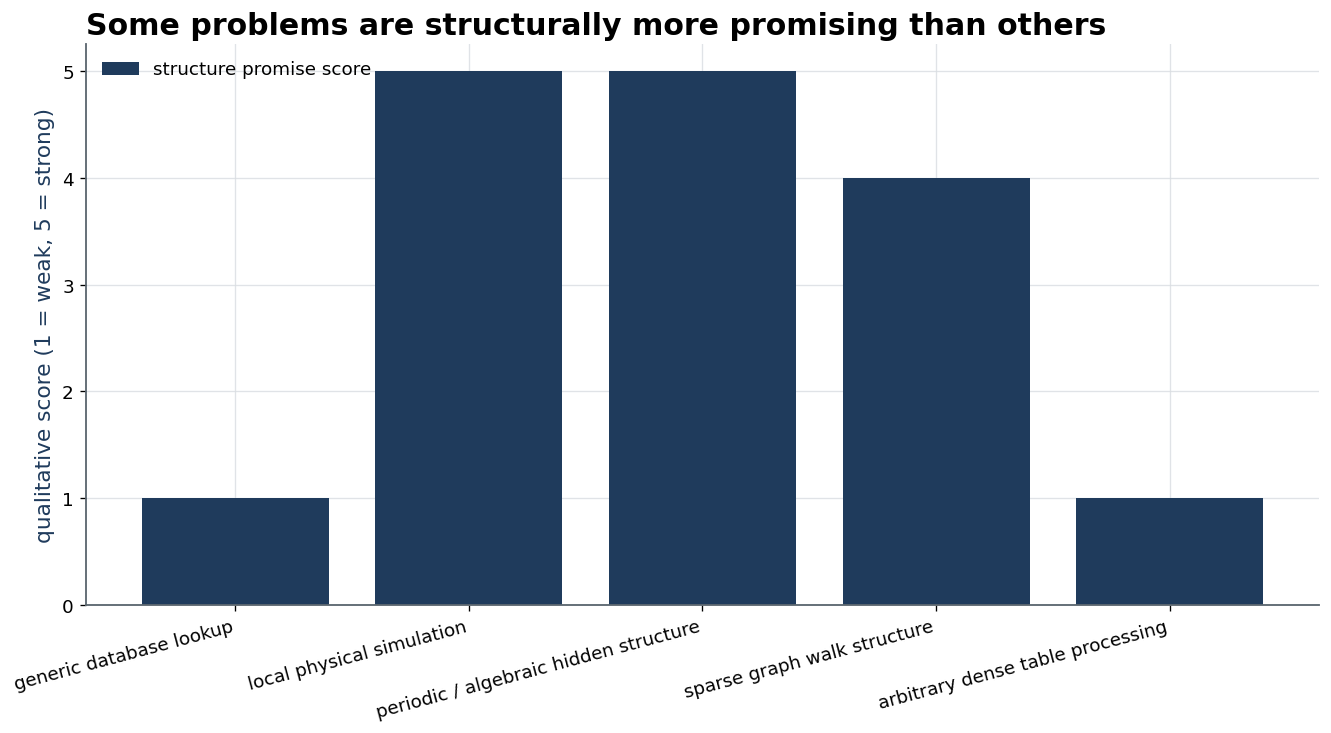

In [8]:
plot_grouped_bars(
    structure_df['Problem family'],
    {'structure promise score': structure_df['Structure promise score']},
    title='Some problems are structurally more promising than others',
    ylabel='qualitative score (1 = weak, 5 = strong)',
)
plt.xticks(rotation=15, ha='right')
plt.show()


The scores are pedagogical, not canonical. Their purpose is to force the first question: is the claimed advantage attached to meaningful structure, or is it attached only to optimism?


In [9]:
structure_eval_df = structure_df.copy()
structure_eval_df['Checklist reading'] = [
    'risky: weak structural leverage',
    'promising: native-looking structure',
    'promising: regularity may support specialized methods',
    'mixed but interesting',
    'risky: likely dominated by input handling',
]
display_wrapped(structure_eval_df)


,Problem family,Structure promise score,Why,Checklist reading
0,generic database lookup,1,little algorithmic leverage beyond raw access,risky: weak structural leverage
1,local physical simulation,5,the problem already has quantum-like locality and interference structure,promising: native-looking structure
2,periodic / algebraic hidden structure,5,regularity can support specialized algorithmic tricks,promising: regularity may support specialized methods
3,sparse graph walk structure,4,connectivity pattern may create exploitable dynamics,mixed but interesting
4,arbitrary dense table processing,1,dense arbitrary data often behaves like a loading problem first,risky: likely dominated by input handling


In [10]:
display_wrapped(Markdown(markdown_box(
    'Problem structure matters because quantum advantage is rarely a generic property of “hard problems.” It usually depends on having something mathematically or physically exploitable.'
)))


> **Takeaway:**
> Problem structure matters because quantum advantage is rarely a generic property of “hard problems.” It usually depends on having something mathematically or physically exploitable.

In [11]:
display_wrapped(Markdown(instructor_prompt(
    'What kinds of structure would make you more willing to take a quantum speedup claim seriously before seeing implementation details?'
)))


> **Instructor Prompt:**
> What kinds of structure would make you more willing to take a quantum speedup claim seriously before seeing implementation details?

## 3. Checklist 2: What problem class are we dealing with?

**Concept question:** What does the problem-class label tell us, and what does it still leave unresolved about practical quantum advantage?


Problem classes help organize expectations, but they are not automatic decision rules. A class label can tell us whether solving, checking, or hardness is the central issue. It does **not** automatically tell us that a practical quantum advantage exists.


In [12]:
class_checklist_df = pd.DataFrame(
    {
        'Class': [
            'P (Polynomial-time solvable)',
            'NP (Nondeterministic polynomial-time)',
            'NP-hard',
            'NP-complete',
            'BQP (Bounded-error quantum polynomial time)',
        ],
        'What it tells you': [
            'efficient classical algorithms are already known',
            'candidate solutions can be checked efficiently',
            'hardness warning sign',
            'checkable and hardness-central inside NP',
            'efficient quantum algorithms are known in the model',
        ],
        'What it does not tell you': [
            'that no practical quantum improvement is possible',
            'that finding solutions is easy',
            'that a practical quantum win exists',
            'that hardware can realize the idea efficiently',
            'that end-to-end advantage is automatic on real devices',
        ],
    }
)


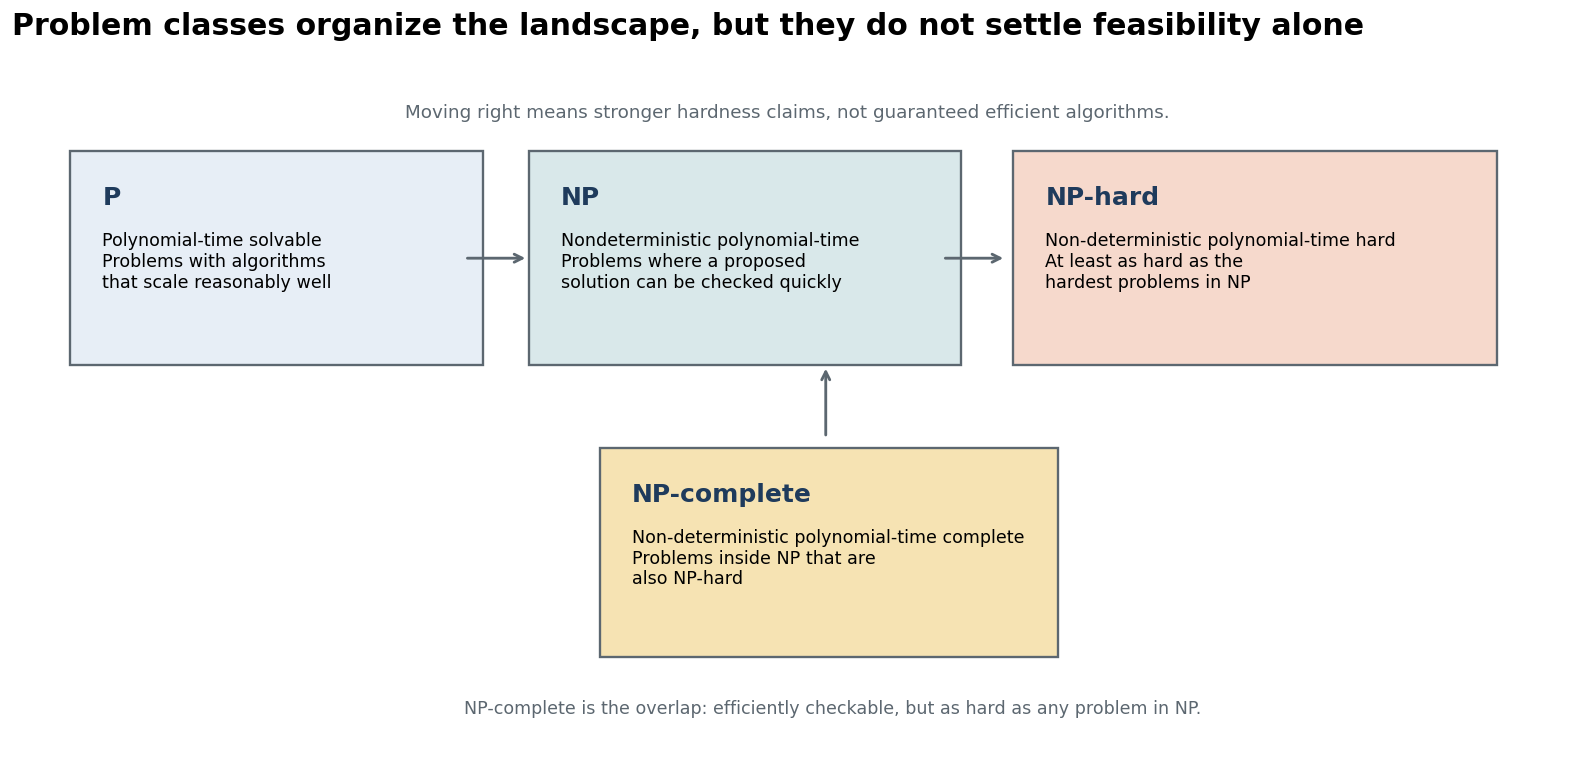

In [13]:
plot_problem_class_map(
    title='Problem classes organize the landscape, but they do not settle feasibility alone',
)
plt.show()


The class map is useful because it disciplines what kind of claim is even being made. But class membership alone does not certify practical advantage. It still leaves open questions about structure, I/O, hardware, and classical competition.


In [14]:
display_wrapped(class_checklist_df)


,Class,What it tells you,What it does not tell you
0,P (Polynomial-time solvable),efficient classical algorithms are already known,that no practical quantum improvement is possible
1,NP (Nondeterministic polynomial-time),candidate solutions can be checked efficiently,that finding solutions is easy
2,NP-hard,hardness warning sign,that a practical quantum win exists
3,NP-complete,checkable and hardness-central inside NP,that hardware can realize the idea efficiently
4,BQP (Bounded-error quantum polynomial time),efficient quantum algorithms are known in the model,that end-to-end advantage is automatic on real devices


In [15]:
display_wrapped(Markdown(markdown_box(
    'Problem class is one input into judgment, not the whole judgment. A speedup claim still needs structure, realistic I/O, manageable overhead, and a strong classical baseline.'
)))


> **Takeaway:**
> Problem class is one input into judgment, not the whole judgment. A speedup claim still needs structure, realistic I/O, manageable overhead, and a strong classical baseline.

In [16]:
display_wrapped(Markdown(instructor_prompt(
    'If someone says a task is “in BQP,” what additional questions would you still ask before interpreting that as practical advantage?'
)))


> **Instructor Prompt:**
> If someone says a task is “in BQP,” what additional questions would you still ask before interpreting that as practical advantage?

## 4. Checklist 3: What is the input/output model?

**Concept question:** Are we assuming a realistic way to get information into the computation and a realistic way to get useful information back out?


Input and output assumptions can quietly decide whether a claimed gain survives. If the input is huge and expensive to encode, or if the output requires many repeated measurements to become informative, then the end-to-end picture can change dramatically.


In [17]:
io_df = pd.DataFrame(
    {
        'Scenario': [
            'compact promise input + compact answer',
            'dense classical dataset + tiny quantum core',
            'sampling task with many required shots',
            'local observable from a structured quantum system',
        ],
        'Input burden score': [1, 5, 2, 2],
        'Output burden score': [1, 3, 5, 2],
        'Reading': [
            'favorable',
            'risky on the input side',
            'risky on the output side',
            'mixed but often more natural than generic data loading',
        ],
    }
)


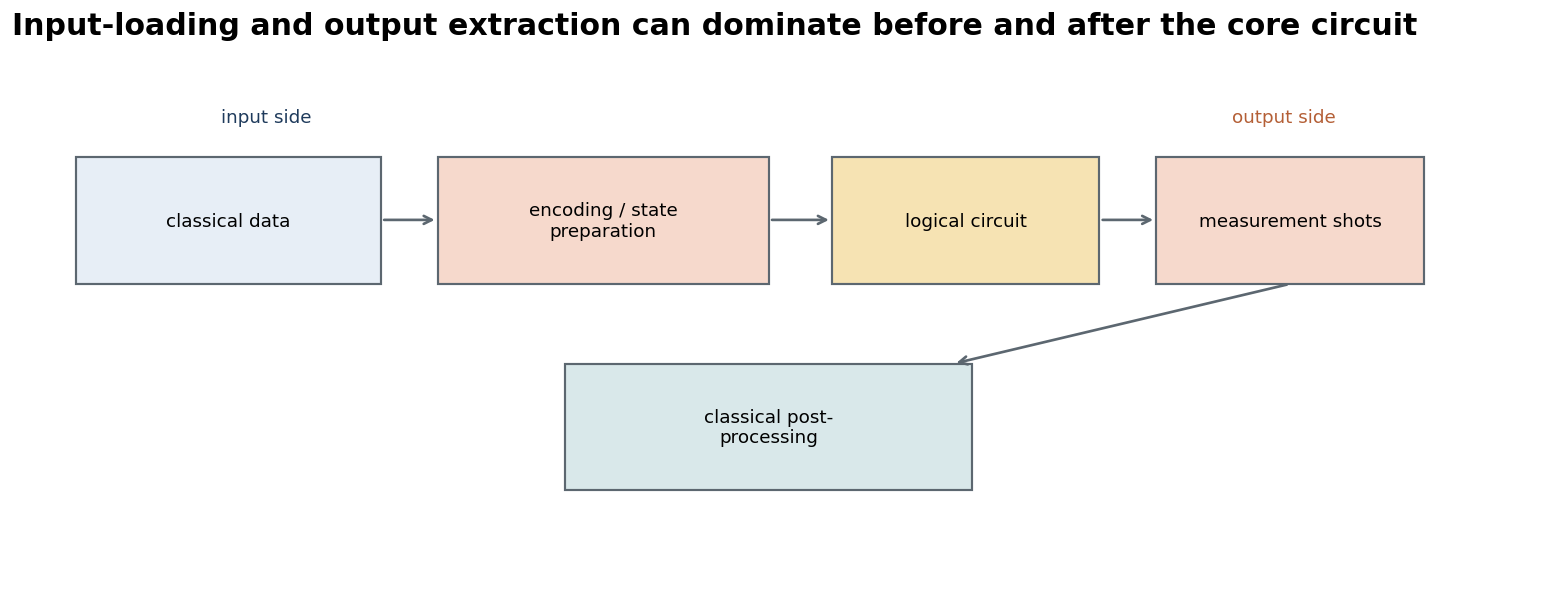

In [18]:
plot_io_constraint_summary(
    title='Input-loading and output extraction can dominate before and after the core circuit',
)
plt.show()


The central warning is simple: if the argument for speedup lives only in the core circuit, but the expensive work lives in encoding or repeated measurement, then the total claim is weaker than it first appears.


In [19]:
display_wrapped(io_df)


,Scenario,Input burden score,Output burden score,Reading
0,compact promise input + compact answer,1,1,favorable
1,dense classical dataset + tiny quantum core,5,3,risky on the input side
2,sampling task with many required shots,2,5,risky on the output side
3,local observable from a structured quantum system,2,2,mixed but often more natural than generic data loading


In [20]:
display_wrapped(Markdown(markdown_box(
    'Input-loading and output access are not side issues. They are often where an idealized advantage becomes much less persuasive.'
)))


> **Takeaway:**
> Input-loading and output access are not side issues. They are often where an idealized advantage becomes much less persuasive.

In [21]:
display_wrapped(Markdown(instructor_prompt(
    'Would you trust a dramatic speedup claim if the input is huge classical data but the encoding and measurement story is vague? Why not?'
)))


> **Instructor Prompt:**
> Would you trust a dramatic speedup claim if the input is huge classical data but the encoding and measurement story is vague? Why not?

## 5. Checklist 4: What hardware resources and overheads matter?

**Concept question:** Even if the logical algorithm looks attractive, what implementation costs must still be paid on real hardware?


Earlier we saw that a quantum workflow is a pipeline, not only a logical circuit. Here we compress that lesson into a checklist: qubit count, circuit depth, topology, routing, repeated shots, and classical post-processing all matter. The key question is whether those overheads remain secondary or become dominant.


In [22]:
hardware_categories = [
    'logical circuit only',
    '+ qubit / layout limits',
    '+ routing overhead',
    '+ repeated shots',
]
hardware_components = {
    'core logic': [12, 12, 12, 12],
    'layout / mapping': [0, 10, 10, 10],
    'routing': [0, 0, 16, 16],
    'shots + post': [0, 0, 0, 22],
}

hardware_check_df = pd.DataFrame(
    {
        'Resource or overhead': ['qubits', 'depth', 'topology', 'routing', 'repeated runs'],
        'Why it matters': [
            'insufficient qubits can block embedding',
            'deep circuits stress coherence and noise budgets',
            'connectivity shapes what is local',
            'nonlocal interactions can add extra movement',
            'statistical confidence may require many shots',
        ],
    }
)


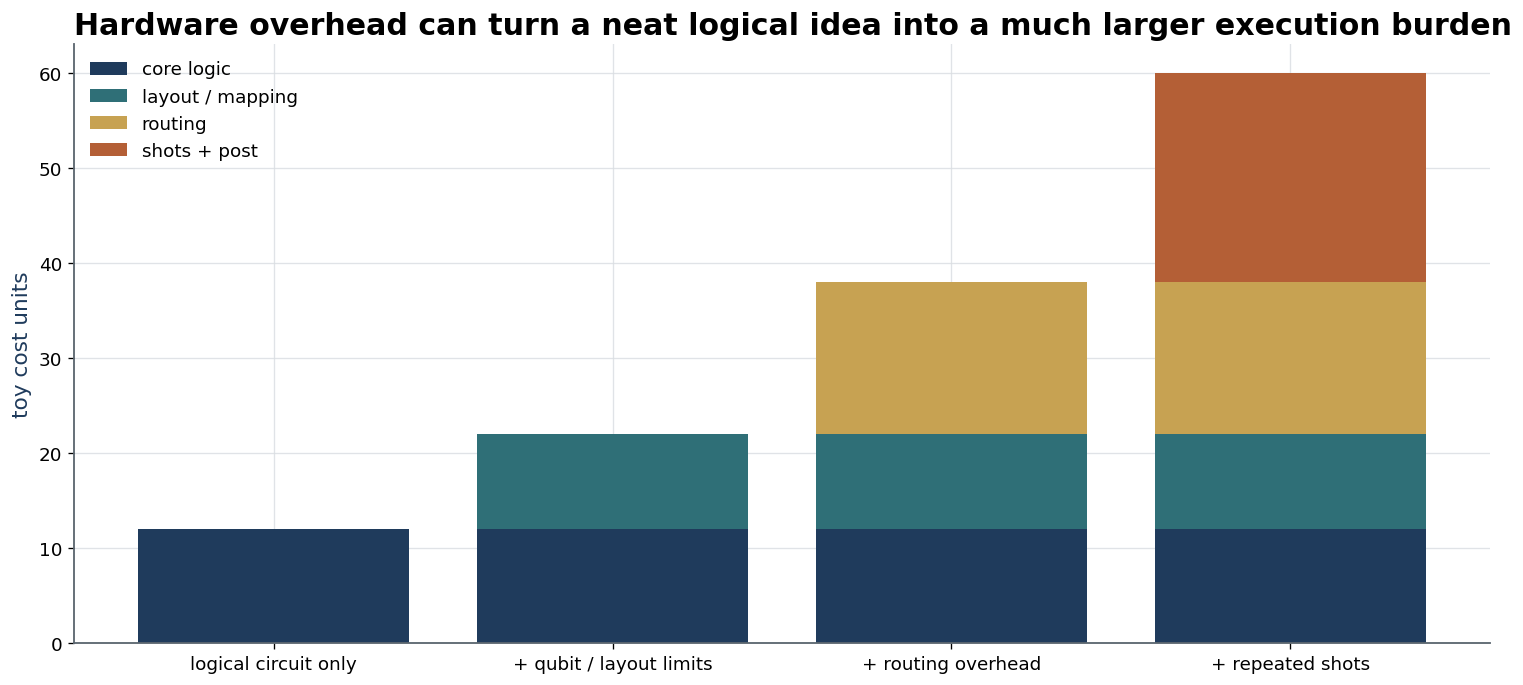

In [23]:
plot_stacked_cost_bars(
    hardware_categories,
    hardware_components,
    title='Hardware overhead can turn a neat logical idea into a much larger execution burden',
    ylabel='toy cost units',
)
plt.show()


The stacked view is a systems reminder. The logical circuit may still be the intellectual core, but the hardware-visible burden can be much larger once layout, routing, and repeated measurement are counted.


In [24]:
display_wrapped(hardware_check_df)


,Resource or overhead,Why it matters
0,qubits,insufficient qubits can block embedding
1,depth,deep circuits stress coherence and noise budgets
2,topology,connectivity shapes what is local
3,routing,nonlocal interactions can add extra movement
4,repeated runs,statistical confidence may require many shots


In [25]:
display_wrapped(Markdown(markdown_box(
    'Hardware feasibility is part of the claim, not an afterthought. A speedup that survives only in the logical model may not survive the execution model.'
)))


> **Takeaway:**
> Hardware feasibility is part of the claim, not an afterthought. A speedup that survives only in the logical model may not survive the execution model.

In [26]:
display_wrapped(Markdown(instructor_prompt(
    'Which hardware overhead feels most likely to erase an apparent gain: limited qubits, routing, depth, or repeated shots?'
)))


> **Instructor Prompt:**
> Which hardware overhead feels most likely to erase an apparent gain: limited qubits, routing, depth, or repeated shots?

## 6. Checklist 5: Is the classical baseline strong and honest?

**Concept question:** Are we comparing against a serious classical baseline, or against something weak enough to make almost any alternative look impressive?


A weak classical comparison can produce an artificial “advantage.” Honest evaluation requires a strong baseline, the same problem definition, the same output target, and comparable accounting of preprocessing and post-processing. Otherwise the comparison is tilted before it starts.


In [27]:
baseline_df = pd.DataFrame(
    {
        'Comparison habit': [
            'compare against a naive or outdated classical method',
            'ignore preprocessing on one side only',
            'use different output-quality targets',
            'benchmark only the most flattering metric',
            'compare against the strongest practical classical baseline',
        ],
        'Checklist reading': [
            'unfair',
            'unfair',
            'unfair',
            'unfair',
            'fair',
        ],
    }
)


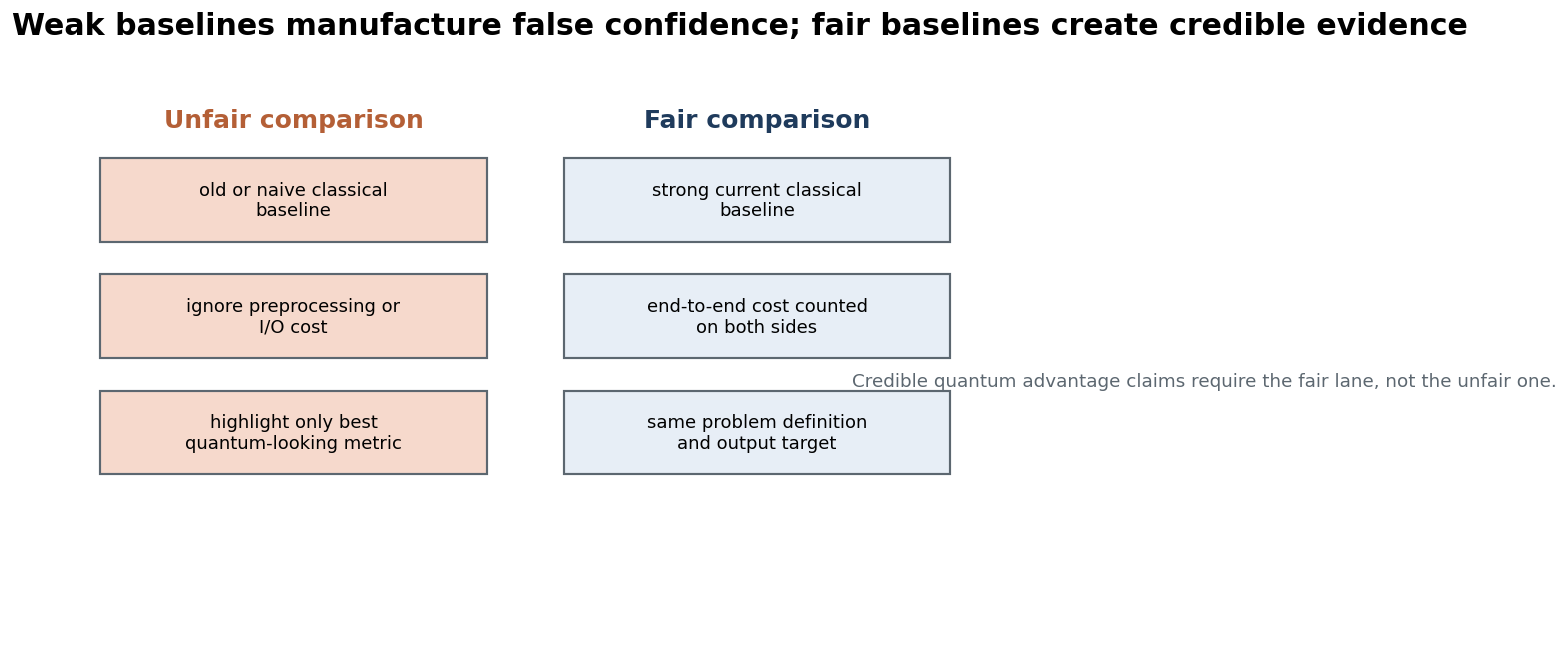

In [28]:
plot_baseline_comparison(
    title='Weak baselines manufacture false confidence; fair baselines create credible evidence',
)
plt.show()


This section is about epistemic hygiene. If the classical comparison is weak, the quantum claim is weak too, even if the quantum side contains genuinely interesting ideas.


In [29]:
display_wrapped(baseline_df)


,Comparison habit,Checklist reading
0,compare against a naive or outdated classical method,unfair
1,ignore preprocessing on one side only,unfair
2,use different output-quality targets,unfair
3,benchmark only the most flattering metric,unfair
4,compare against the strongest practical classical baseline,fair


In [30]:
display_wrapped(Markdown(markdown_box(
    'A weak classical baseline is not persuasive evidence of quantum advantage. Fair comparison is part of the claim, not a presentation detail.'
)))


> **Takeaway:**
> A weak classical baseline is not persuasive evidence of quantum advantage. Fair comparison is part of the claim, not a presentation detail.

In [31]:
display_wrapped(Markdown(instructor_prompt(
    'What is the easiest way to make a quantum claim look stronger than it really is without changing the quantum algorithm at all?'
)))


> **Instructor Prompt:**
> What is the easiest way to make a quantum claim look stronger than it really is without changing the quantum algorithm at all?

## 7. Case studies: plausible, unclear, or hype-prone?

**Concept question:** If we apply the checklist consistently, how do different toy quantum-advantage narratives look?


These case studies are intentionally short and classroom-friendly. They are not meant to settle real research questions. Their purpose is to train judgment by forcing the same checklist onto several different claim styles.


In [32]:
case_df = pd.DataFrame(
    {
        'Case': [
            'structured physical simulation',
            'generic database lookup over huge classical data',
            'graph optimization with many constraints',
            'periodic / algebraic hidden-pattern task',
            'search-like task with many required shots',
        ],
        'Short description': [
            'simulate or sample properties of a structured local quantum system',
            'load a large classical database and hope the quantum core dominates',
            'solve a difficult combinatorial optimization instance',
            'exploit strong algebraic regularity in the problem structure',
            'obtain a small core speedup but need many repeated measurements',
        ],
        'Structure': ['promising', 'risky', 'mixed', 'promising', 'mixed'],
        'Problem class lens': ['mixed', 'mixed', 'risky', 'promising', 'mixed'],
        'Input / output': ['mixed', 'risky', 'mixed', 'mixed', 'risky'],
        'Hardware overhead': ['mixed', 'risky', 'risky', 'mixed', 'risky'],
        'Classical baseline risk': ['mixed', 'mixed', 'mixed', 'mixed', 'mixed'],
        'Judgment': ['plausible', 'hype-prone', 'unclear', 'plausible', 'unclear'],
        'Dominant concern(s)': [
            'hardware scale and noise, but structure is favorable',
            'input-loading dominates and the task lacks special structure',
            'hardness and overhead may overwhelm any proposed gain',
            'structure is favorable, but implementation still matters',
            'output estimation cost may erase the apparent gain',
        ],
        'Reasoning': [
            'the problem structure is naturally aligned with quantum-style modeling, so the claim is plausible if hardware cost is controlled',
            'the task looks like a loading problem more than a quantum-computation problem, so the claim is hype-prone unless the model changes',
            'the task is structurally interesting but still burdened by hardness, mapping, and strong classical competition, so the right label is unclear',
            'strong regularity makes the claim more plausible, but practical feasibility still depends on encoding, precision, and hardware',
            'the core idea may be interesting, but repeated shots and weak output concentration make the end-to-end claim unclear',
        ],
    }
)


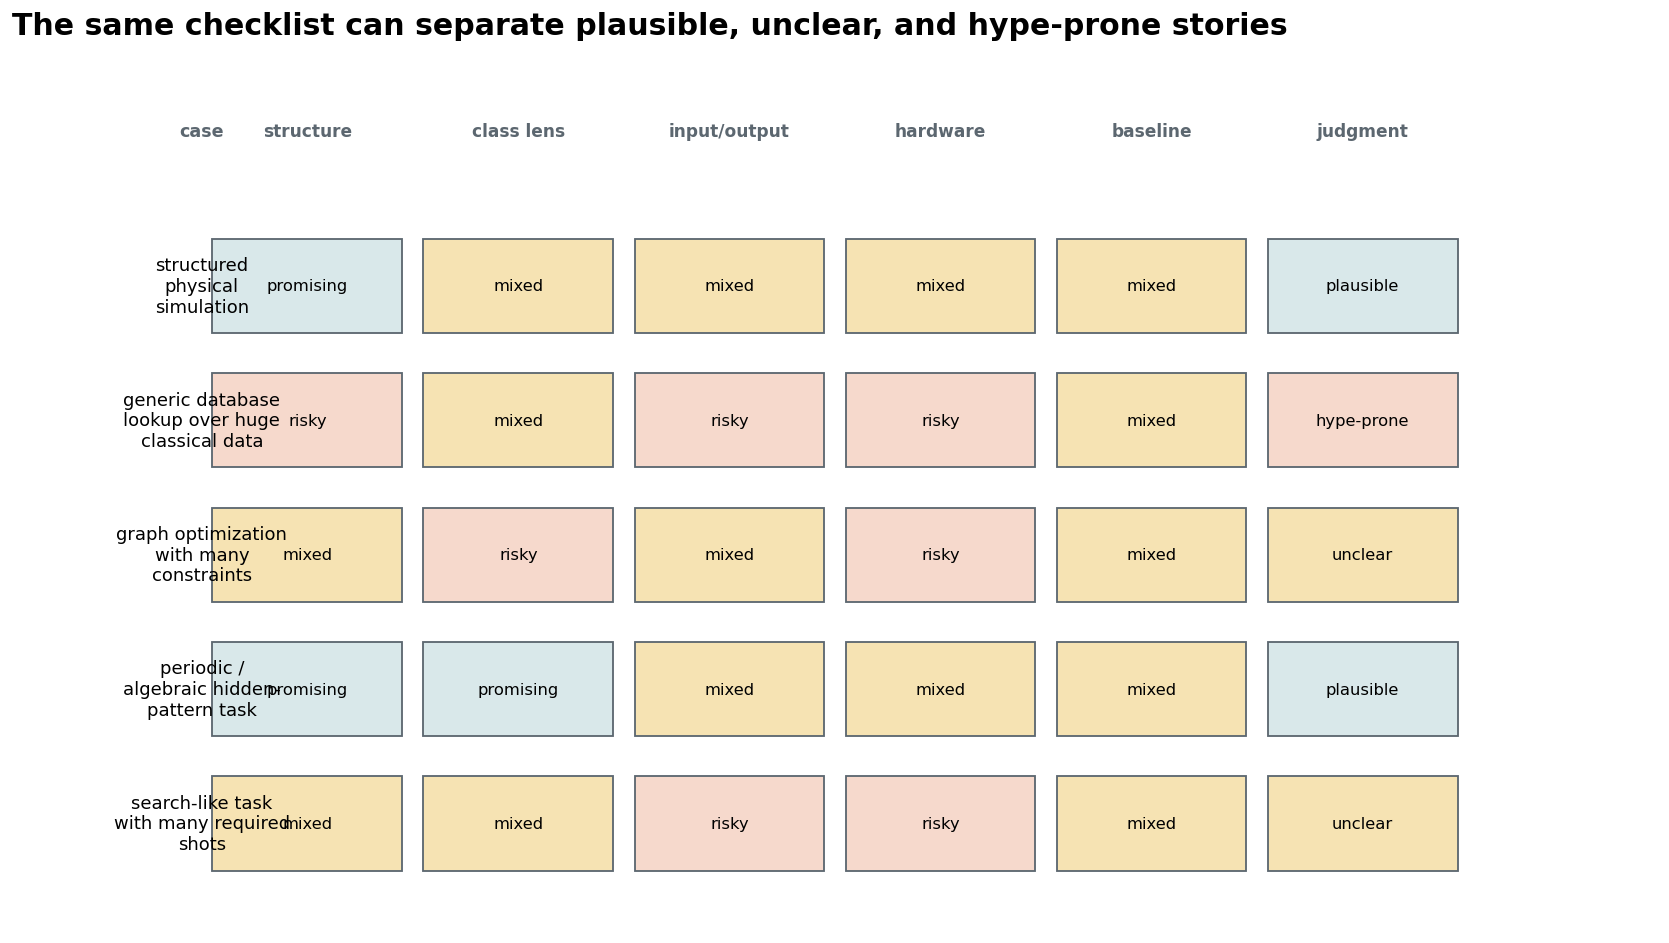

In [33]:
plot_case_study_matrix(
    case_df['Case'],
    ['structure', 'class lens', 'input/output', 'hardware', 'baseline'],
    case_df[['Structure', 'Problem class lens', 'Input / output', 'Hardware overhead', 'Classical baseline risk']].values.tolist(),
    judgments=case_df['Judgment'],
    title='The same checklist can separate plausible, unclear, and hype-prone stories',
)
plt.show()


The matrix is not a scoring machine. It is a disciplined way to separate different kinds of weakness. Some cases are risky because they lack structure. Others are risky because input/output or hardware costs dominate. That difference matters.


In [34]:
display_wrapped(case_df[['Case', 'Short description', 'Dominant concern(s)', 'Judgment', 'Reasoning']])


,Case,Short description,Dominant concern(s),Judgment,Reasoning
0,structured physical simulation,simulate or sample properties of a structured local quantum system,"hardware scale and noise, but structure is favorable",plausible,"the problem structure is naturally aligned with quantum-style modeling, so the claim is plausible if hardware cost is controlled"
1,generic database lookup over huge classical data,load a large classical database and hope the quantum core dominates,input-loading dominates and the task lacks special structure,hype-prone,"the task looks like a loading problem more than a quantum-computation problem, so the claim is hype-prone unless the model changes"
2,graph optimization with many constraints,solve a difficult combinatorial optimization instance,hardness and overhead may overwhelm any proposed gain,unclear,"the task is structurally interesting but still burdened by hardness, mapping, and strong classical competition, so the right label is unclear"
3,periodic / algebraic hidden-pattern task,exploit strong algebraic regularity in the problem structure,"structure is favorable, but implementation still matters",plausible,"strong regularity makes the claim more plausible, but practical feasibility still depends on encoding, precision, and hardware"
4,search-like task with many required shots,obtain a small core speedup but need many repeated measurements,output estimation cost may erase the apparent gain,unclear,"the core idea may be interesting, but repeated shots and weak output concentration make the end-to-end claim unclear"


In [35]:
display_wrapped(Markdown(markdown_box(
    'A good checklist does not merely sort cases into “good” and “bad.” It reveals *why* a claim is plausible, unclear, or hype-prone.'
)))


> **Takeaway:**
> A good checklist does not merely sort cases into “good” and “bad.” It reveals *why* a claim is plausible, unclear, or hype-prone.

In [36]:
display_wrapped(Markdown(instructor_prompt(
    'Which case study changed category the most once you forced yourself to consider input/output, hardware, and baseline rather than only the core idea?'
)))


> **Instructor Prompt:**
> Which case study changed category the most once you forced yourself to consider input/output, hardware, and baseline rather than only the core idea?

## 8. A final framework for judging quantum advantage

**Concept question:** If you had to remember only one reusable framework after this lecture, what should it be?


The final goal is not memorizing phrases. It is building a reusable mental routine. When students hear a future claim of quantum advantage, they should know what to ask before deciding whether the claim sounds plausible, unclear, or hype-prone.


In [37]:
final_steps = [
    'What problem structure is being exploited?',
    'What does the problem-class language really imply here?',
    'How is the input loaded and how is the output extracted?',
    'What hardware, routing, depth, and shot costs are being paid?',
    'Is the classical baseline strong, fair, and up to date?',
    'After all of that, how strong is the end-to-end case for advantage?',
]

final_framework_df = pd.DataFrame(
    {
        'Checklist question': final_steps,
        'Positive signal': [
            'clear exploitable regularity or natural quantum structure',
            'class language is used carefully and modestly',
            'compact or realistic I/O assumptions',
            'overheads remain secondary rather than dominant',
            'comparison uses a strong modern classical baseline',
            'the claim still looks strong after all previous checks',
        ],
        'Warning signal': [
            'generic arbitrary data with no useful pattern',
            'class label is treated as a magic answer',
            'encoding or measurement story is vague',
            'routing, shots, or layout dominate the cost',
            'baseline is weak, outdated, or unfair',
            'the claim depends on ignoring one of the earlier costs',
        ],
    }
)


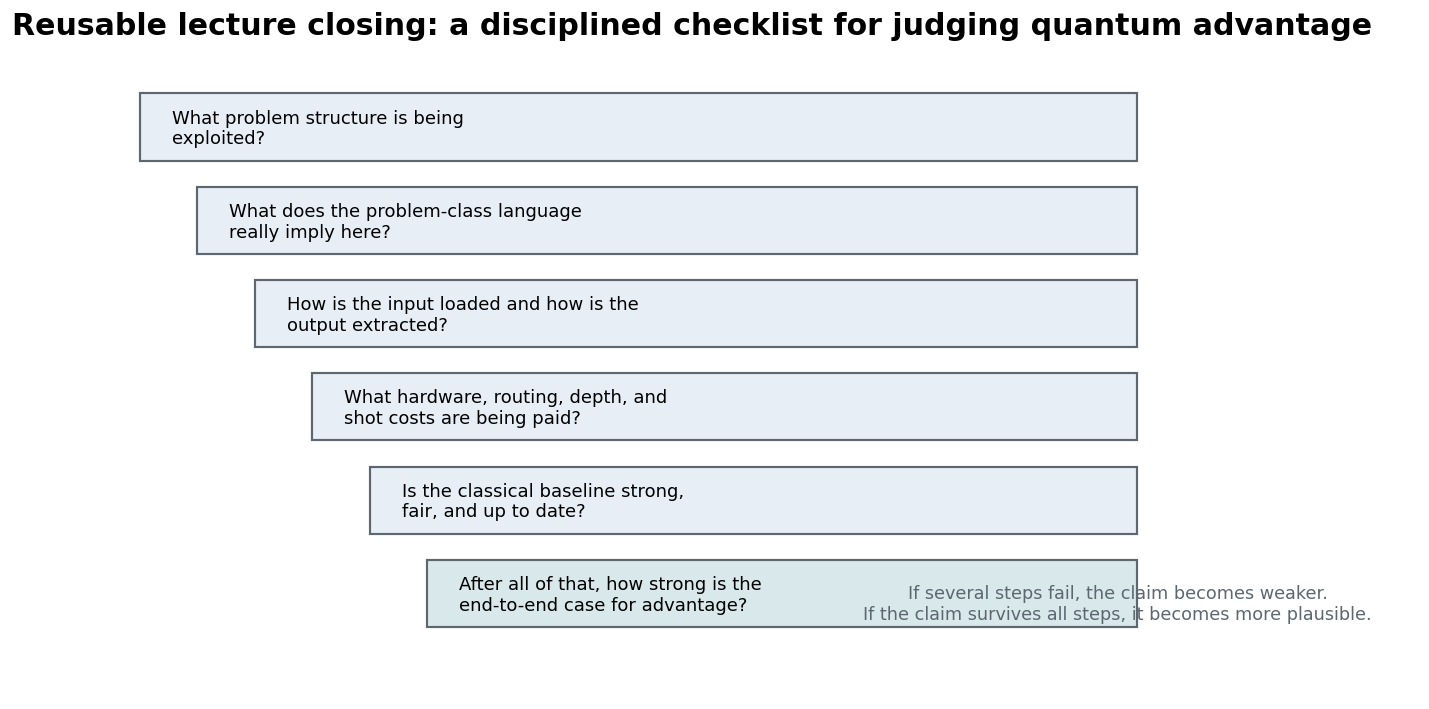

In [38]:
plot_checklist_ladder(
    final_steps,
    title='Reusable lecture closing: a disciplined checklist for judging quantum advantage',
)
plt.show()


This ladder is the closing habit the notebook wants to build. Students should finish the lecture less impressed by slogans and more interested in the exact assumptions that make a claim stand or collapse.


In [39]:
display_wrapped(final_framework_df)


,Checklist question,Positive signal,Warning signal
0,What problem structure is being exploited?,clear exploitable regularity or natural quantum structure,generic arbitrary data with no useful pattern
1,What does the problem-class language really imply here?,class language is used carefully and modestly,class label is treated as a magic answer
2,How is the input loaded and how is the output extracted?,compact or realistic I/O assumptions,encoding or measurement story is vague
3,"What hardware, routing, depth, and shot costs are being paid?",overheads remain secondary rather than dominant,"routing, shots, or layout dominate the cost"
4,"Is the classical baseline strong, fair, and up to date?",comparison uses a strong modern classical baseline,"baseline is weak, outdated, or unfair"
5,"After all of that, how strong is the end-to-end case for advantage?",the claim still looks strong after all previous checks,the claim depends on ignoring one of the earlier costs


In [40]:
display_wrapped(Markdown(markdown_box(
    'Quantum advantage should be treated as a disciplined systems claim. A theoretical speedup is not enough; the end-to-end workflow, hardware burden, and classical comparison must also survive scrutiny.'
)))


> **Takeaway:**
> Quantum advantage should be treated as a disciplined systems claim. A theoretical speedup is not enough; the end-to-end workflow, hardware burden, and classical comparison must also survive scrutiny.

In [41]:
display_wrapped(Markdown(instructor_prompt(
    'After this lecture sequence, what single question would you ask first when someone claims a dramatic quantum speedup?'
)))


> **Instructor Prompt:**
> After this lecture sequence, what single question would you ask first when someone claims a dramatic quantum speedup?

## 9. Recap / takeaways


In [42]:
display_wrapped(Markdown(markdown_box(
    'Real quantum advantage is not a slogan. It is an end-to-end judgment that depends on problem structure, problem class, input/output assumptions, hardware overhead, and an honest classical baseline. This notebook series ends by turning those ideas into a reusable feasibility checklist.',
    title='Recap'
)))


> **Recap:**
> Real quantum advantage is not a slogan. It is an end-to-end judgment that depends on problem structure, problem class, input/output assumptions, hardware overhead, and an honest classical baseline. This notebook series ends by turning those ideas into a reusable feasibility checklist.

## 10. Questions for students

- Why is a theoretical speedup alone not enough to justify a practical advantage claim?
- What kinds of problem structure make you more open to a quantum advantage argument?
- Why does problem class help organize the discussion without deciding it automatically?
- How can input-loading and repeated measurement weaken an otherwise attractive story?
- Why is a weak classical baseline one of the easiest ways to create hype?
- Which checklist question do you expect to be most useful in future lectures or papers?
